## SBA
### Data Analysis and Visualization with Python

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

### Section 1: Data Analysis 

In [3]:
# Task 1 : Data Ingestion 
# Read Data from woocommerce-product-export.csv and import
df = pd.read_csv("woocommerce-product-export.csv")

In [4]:
# Task 2: Column Structure and Metadata 
# Show a concise summary of the columns using info() method
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   month_number  12 non-null     int64
 1   facecream     12 non-null     int64
 2   facewash      12 non-null     int64
 3   toothpaste    12 non-null     int64
 4   bathingsoap   12 non-null     int64
 5   shampoo       12 non-null     int64
 6   moisturizer   12 non-null     int64
 7   total_units   12 non-null     int64
 8   total_profit  12 non-null     int64
dtypes: int64(9)
memory usage: 996.0 bytes


### DataFrame we are working and its contents (column names, non-null counts, data types (int64))

In [5]:
rows, cols = df.shape
print(f'Rows: {rows}')
print(f'Cols: {cols}')

Rows: 12
Cols: 9


In [6]:
# Frequency count of unique values for column 'month'-(categorical data)
df['month_number'].value_counts()

month_number
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
Name: count, dtype: int64

### Verifies that all 12 months appear exactly once and confirms no months are imputed or duplicated

In [7]:
#Task 3: Statistical Profiling & Data Integrity
# Show a summary of the statistics pertaning to the columns 
print("\n---Descriptive Statistics ---")
df.describe()



---Descriptive Statistics ---


,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.00000,12.000000
mean,6.500000,2873.333333,1542.916667,5825.833333,9500.833333,2117.500000,1542.916667,26027.50000,260275.000000
std,3.605551,584.595172,316.733745,1242.032486,2348.095779,617.724931,316.733745,7014.36594,70143.659404
min,1.000000,1990.000000,1120.000000,4550.000000,6100.000000,1200.000000,1120.000000,18330.00000,183300.000000
25%,3.750000,2460.000000,1305.000000,4862.500000,8015.000000,1795.000000,1305.000000,21065.00000,210650.000000
50%,6.500000,2830.000000,1527.500000,5530.000000,9090.000000,1995.000000,1527.500000,22935.00000,229350.000000
75%,9.250000,3435.000000,1765.000000,6400.000000,10045.000000,2325.000000,1765.000000,29667.50000,296675.000000
max,12.000000,3700.000000,2100.000000,8300.000000,14400.000000,3550.000000,2100.000000,41280.00000,412800.000000


In [8]:
# Data Integrity Checks
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
month_number    0
facecream       0
facewash        0
toothpaste      0
bathingsoap     0
shampoo         0
moisturizer     0
total_units     0
total_profit    0
dtype: int64


### Checked for missing values. Confirming 0 missing values across all columns, ensuring total profit calculations are complete.

In [9]:
print("\n--- Duplicate Records Count ---")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")


--- Duplicate Records Count ---
Total Duplicate Rows: 0


### Verified data uniqueness. No duplicate records were detected, confirming each row uniquely represents a single month.

In [10]:
# Task 4: Print the First 5 rows.
print("\n --- First 5 Rows ---")
print(df.head())


 --- First 5 Rows ---
   month_number  facecream  facewash  toothpaste  bathingsoap  shampoo  \
0             1       2500      1500        5200         9200     1200   
1             2       2630      1200        5100         6100     2100   
2             3       2140      1340        4550         9550     3550   
3             4       3400      1130        5870         8870     1870   
4             5       3600      1740        4560         7760     1560   

   moisturizer  total_units  total_profit  
0         1500        21100        211000  
1         1200        18330        183300  
2         1340        22470        224700  
3         1130        22270        222700  
4         1740        20960        209600  


### Inspeted the top 5 rows to verify proper CSV header parsing, column alignment, and initial numerical values across early-year product sales log.

In [11]:
# Task 5: Print the Last 5 rows.
print("\n--- Last 5 Rows ---")
print(df.tail())


--- Last 5 Rows ---
    month_number  facecream  facewash  toothpaste  bathingsoap  shampoo  \
7              8       3700      1400        5860         9960     2860   
8              9       3540      1780        6100         8100     2100   
9             10       1990      1890        8300        10300     2300   
10            11       2340      2100        7300        13300     2400   
11            12       2900      1760        7400        14400     1800   

    moisturizer  total_units  total_profit  
7          1400        36140        361400  
8          1780        23400        234000  
9          1890        26670        266700  
10         2100        41280        412800  
11         1760        30020        300200  


### Inspecting the final 5 rows ensures year-end data is clealy captured without trailing blank rows.

In [12]:
# Task 6: Print 'total_profit' and 'month_number' columns only
print("\n--- Total Profit and Month Number Columns ---")
print(df[['total_profit','month_number']])


--- Total Profit and Month Number Columns ---
    total_profit  month_number
0         211000             1
1         183300             2
2         224700             3
3         222700             4
4         209600             5
5         201400             6
6         295500             7
7         361400             8
8         234000             9
9         266700            10
10        412800            11
11        300200            12


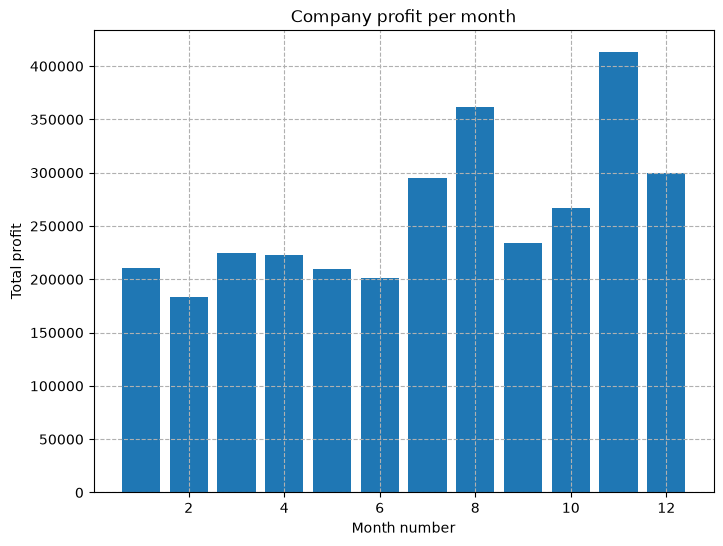

In [13]:
# Task 7: Total Monthly Profit Bar Plot
plt.figure(figsize=(8, 6))
plt.bar(df['month_number'], df['total_profit'])
plt.xlabel('Month number')
plt.ylabel('Total profit')
plt.title('Company profit per month')
plt.grid(True, linestyle='--')
plt.show()

### Insights from Total Monthly Profit Bar Plot
- It highlights clearly monthly financial variation throught the year
- With maximum profit revenue month  November at over $400,000 and the least profit revenue month Februray with recorded value of ~$180,000.
- Steady sales during the mid-year and finshing strong  in the last quarter shopping periods.

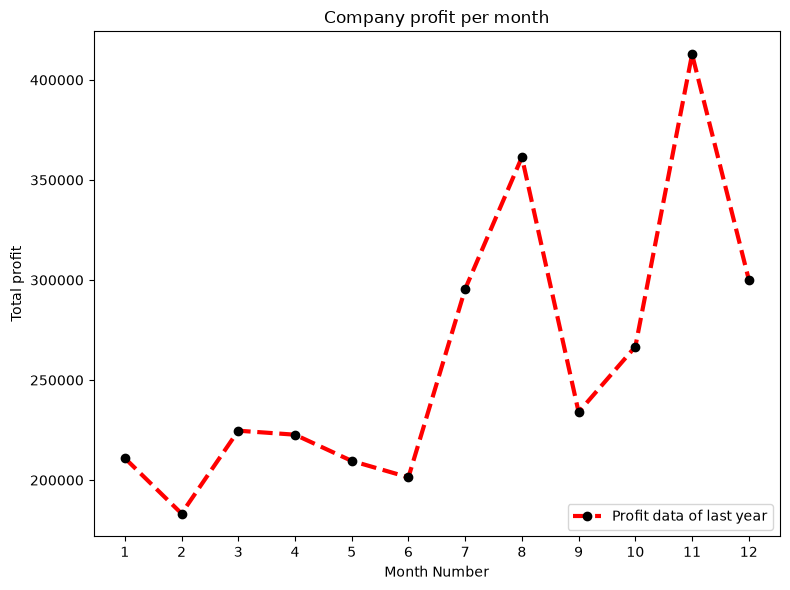

In [14]:
#Task 8: Total profit line plot with specific styling properties 
plt.figure(figsize=(8, 6))
plt.plot(
    df['month_number'],
    df['total_profit'],
    color='red',
    linestyle='--',
    linewidth=3, 
    marker='o',
    markerfacecolor='black',
    markeredgecolor='black',
    label='Profit data of last year'
)
plt.xlabel('Month Number')
plt.ylabel('Total profit')
plt.title('Company profit per month')
plt.xticks(df['month_number'])
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Insights of Total profit line plot
- A general upward trajectory in company profits. 
- Profit spikes recorded in Month 8 and Month 11

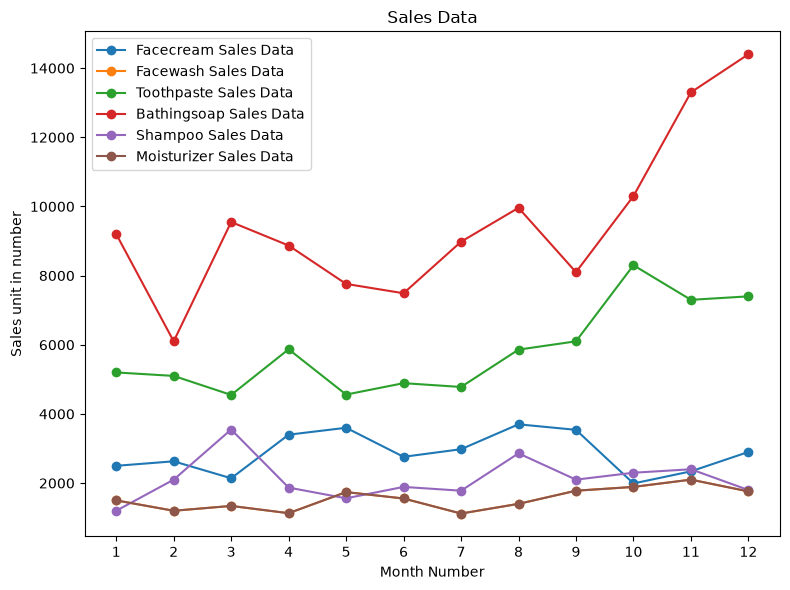

In [15]:
# Task 9: All product sales data using a multi-line plot
plt.figure(figsize=(8, 6))

products = ['facecream', 'facewash', 'toothpaste', 'bathingsoap', 'shampoo', 'moisturizer']

for product in products:
    if product in df.columns:
        plt.plot(df['month_number'], df[product], marker='o', label=f'{product.capitalize()} Sales Data')

plt.xlabel('Month Number')
plt.ylabel('Sales unit in number')
plt.xticks(df['month_number'])
plt.title('Sales Data')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Insights of Mutli-Line Product Sales
- Shows a breakdown of unit sales across all product lines ('facecream', 'facewash', 'toothpaste', 'bathingsoap', 'shampoo' and 'moisturizer')
- Bathingsoap is the most popular product and generates the highest sales throughout the year.
- Toothpase is the second most popular product and shows steady sales throughout the year.

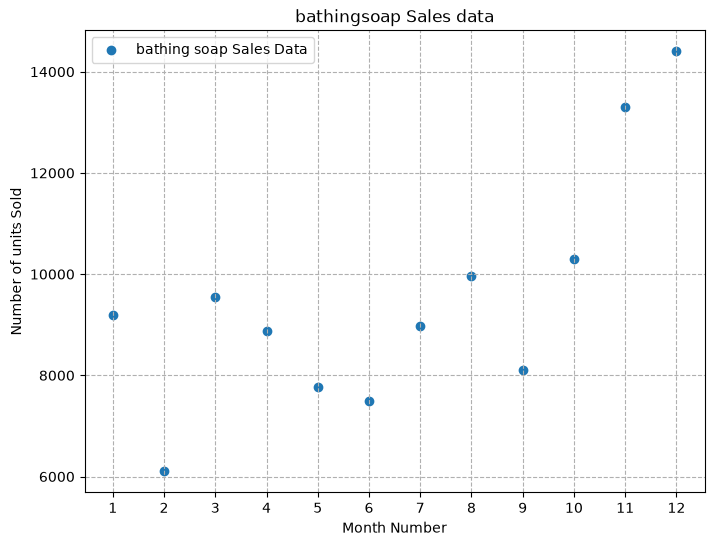

In [16]:
#Task 10: Bathingsoap sales data Scatter Plot with grid style "--"
plt.figure(figsize=(8, 6))
plt.scatter(df['month_number'], df['bathingsoap'], label='bathing soap Sales Data')
plt.xlabel('Month Number')
plt.ylabel('Number of units Sold')
plt.title('bathingsoap Sales data')
plt.grid(True, linestyle='--')
plt.legend(loc='upper left')
plt.xticks(df['month_number'])
plt.tight_layout
plt.show()

### Insights of Most Popular Product Sales Plot
- 'Number of units sold' clusters are disperased throught the year.
- Strong positive assocaition between 'Month Number' and 'units sold' implies poitive correlation - specially in the later half of the year.

### Section 2

In [17]:
date=["25/12","26/12","27/12"]
temp=[8.5,10.5,6.8]


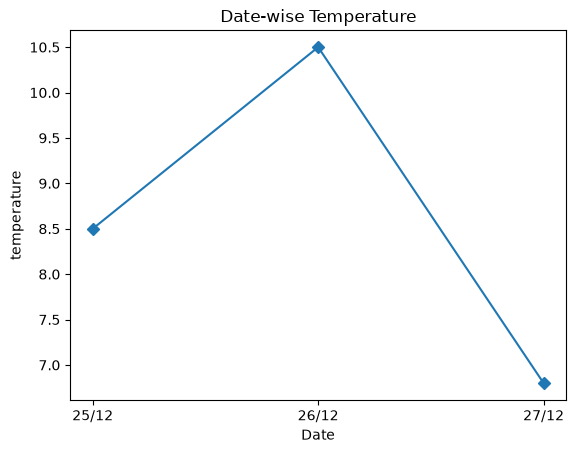

In [18]:
#Task 1: Date-wise Temperature  Line Chart
plt.Figure(figsize=(8, 6))
plt.plot (date, temp, marker='D')
plt.xlabel('Date')
plt.ylabel('temperature')
plt.title('Date-wise Temperature')
plt.tight_layout
plt.show()

### Date-wise Temperature Line Chart shows a spike in temperature on 26/12 and then a sharp drop the following day


In [19]:
height=[121.9,124.5,129.5,134.6,139.7,147.3,152.4,157.5,162.6]
weight=[19.7,21.3,23.5,25.9,28.5,32.1,35.7,39.6,43.2]


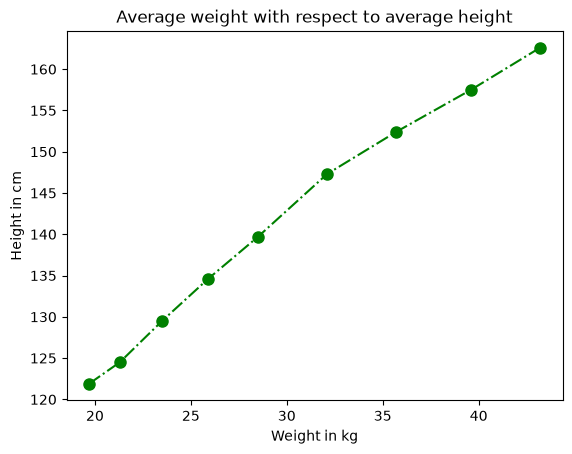

In [20]:
# Task 2: Average weights Vs. Average Height Line Chart
plt.Figure(figsize=(8, 6))
plt.plot (weight, height, color='green', marker='o', linestyle='-.', markersize=8, markerfacecolor='green', markeredgecolor='green', label='Average weight with respect to average height')
plt.xlabel('Weight in kg')
plt.ylabel('Height in cm')
plt.title('Average weight with respect to average height')
plt.tight_layout
plt.show()

### Height vs Weight growth line chart projects a linear correlation between 'Weight in kg' and 'Height in cm'. As weight increases the height increases, this confirms consistent physical development.  